In [62]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-SQ2U05Q\\SQLEXPRESS;"
    "DATABASE=PortfolioProject_MarketingAnalytics;"
    "Trusted_Connection=yes;"
)

conn = pyodbc.connect(conn_str)
print("Connected successfully ")


Connected successfully 


In [63]:

conn = pyodbc.connect(conn_str)

query = """
SELECT 
    TABLE_NAME,
    COLUMN_NAME,
    DATA_TYPE
FROM INFORMATION_SCHEMA.COLUMNS
ORDER BY TABLE_NAME, ORDINAL_POSITION
"""

df_columns = pd.read_sql(query, conn)
df_columns

C:\Users\user\AppData\Local\Temp\ipykernel_10924\3739269231.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_columns = pd.read_sql(query, conn)


,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,customer_journey,JourneyID,smallint
1,customer_journey,CustomerID,tinyint
2,customer_journey,ProductID,tinyint
3,customer_journey,VisitDate,date
4,customer_journey,Stage,nvarchar
5,customer_journey,Action,nvarchar
6,customer_journey,Duration,float
7,customer_reviews,ReviewID,smallint
8,customer_reviews,CustomerID,tinyint
9,customer_reviews,ProductID,tinyint


In [67]:
import pandas as pd

query = """
SELECT Stage
FROM dbo.customer_journey
"""

df = pd.read_sql(query, conn)

df['Stage'].value_counts(dropna=False)


C:\Users\user\AppData\Local\Temp\ipykernel_10924\4130842166.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Stage
Homepage       1692
ProductPage    1370
Checkout        748
homepage         85
productpage      74
checkout         42
Name: count, dtype: int64

In [68]:
import pyodbc
import pandas as pd

# الاتصال بالسيرفر
conn = pyodbc.connect(conn_str)

# استعلام كل الأعمدة لكل جدول في القاعدة الحالية
query = """
SELECT 
    TABLE_SCHEMA,    -- اسم السكيمة
    TABLE_NAME,      -- اسم الجدول
    COLUMN_NAME,     -- اسم العمود
    DATA_TYPE        -- نوع البيانات
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_CATALOG = DB_NAME()  -- بس للقاعدة الحالية
ORDER BY TABLE_SCHEMA, TABLE_NAME, ORDINAL_POSITION
"""

# قراءة النتائج في DataFrame
df_columns = pd.read_sql(query, conn)

# عرض كل الصفوف والأعمدة بدون اختصار
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(df_columns)



C:\Users\user\AppData\Local\Temp\ipykernel_10924\2890782047.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_columns = pd.read_sql(query, conn)


   TABLE_SCHEMA                TABLE_NAME          COLUMN_NAME DATA_TYPE
0           dbo          customer_journey            JourneyID  smallint
1           dbo          customer_journey           CustomerID   tinyint
2           dbo          customer_journey            ProductID   tinyint
3           dbo          customer_journey            VisitDate      date
4           dbo          customer_journey                Stage  nvarchar
5           dbo          customer_journey               Action  nvarchar
6           dbo          customer_journey             Duration     float
7           dbo          customer_reviews             ReviewID  smallint
8           dbo          customer_reviews           CustomerID   tinyint
9           dbo          customer_reviews            ProductID   tinyint
10          dbo          customer_reviews           ReviewDate      date
11          dbo          customer_reviews               Rating   tinyint
12          dbo          customer_reviews          

In [69]:
engagement = pd.read_sql("SELECT * FROM vw_clean_engagement_data", conn)
reviews = pd.read_sql("SELECT * FROM vw_customer_reviews", conn)
journey = pd.read_sql("SELECT * FROM vw_final_clean_journey", conn)
stage_engagement = pd.read_sql("SELECT * FROM vw_stage_engagement", conn)
customers = pd.read_sql("SELECT * FROM vw_customers", conn)
products = pd.read_sql("SELECT * FROM vw_products", conn)
geo = pd.read_sql("SELECT * FROM vw_geography", conn)


C:\Users\user\AppData\Local\Temp\ipykernel_10924\2244207483.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  engagement = pd.read_sql("SELECT * FROM vw_clean_engagement_data", conn)
C:\Users\user\AppData\Local\Temp\ipykernel_10924\2244207483.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  reviews = pd.read_sql("SELECT * FROM vw_customer_reviews", conn)
C:\Users\user\AppData\Local\Temp\ipykernel_10924\2244207483.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  journey = pd.read_sql("SELECT * FROM vw_final_clean_jou

In [70]:

engagement['EngagementDate'] = pd.to_datetime(engagement['EngagementDate'])
journey['VisitDate'] = pd.to_datetime(journey['VisitDate'])
reviews['ReviewDate'] = pd.to_datetime(reviews['ReviewDate'])


## EDA


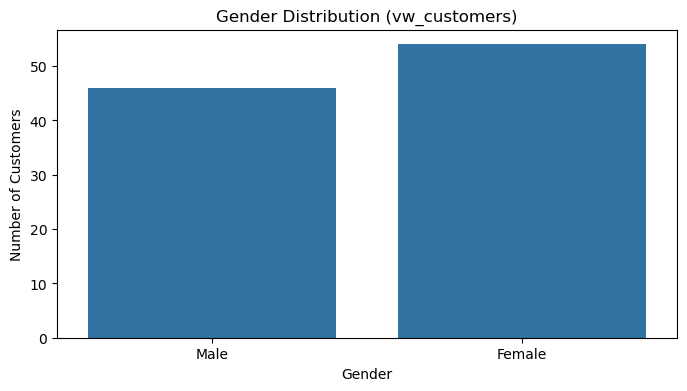

In [79]:
customers = customers.dropna(subset=['Gender'])

plt.figure(figsize=(8,4))
sns.countplot(data=customers, x='Gender')
plt.title('Gender Distribution (vw_customers)')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()


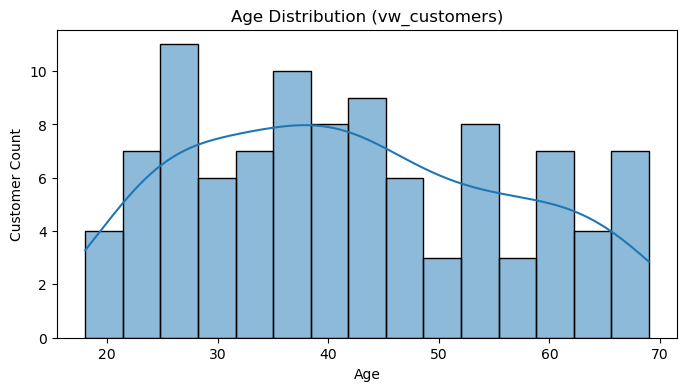

In [80]:
customers = customers.dropna(subset=['Age'])

plt.figure(figsize=(8,4))
sns.histplot(data=customers, x='Age', bins=15, kde=True)
plt.title('Age Distribution (vw_customers)')
plt.xlabel('Age')
plt.ylabel('Customer Count')
plt.show()


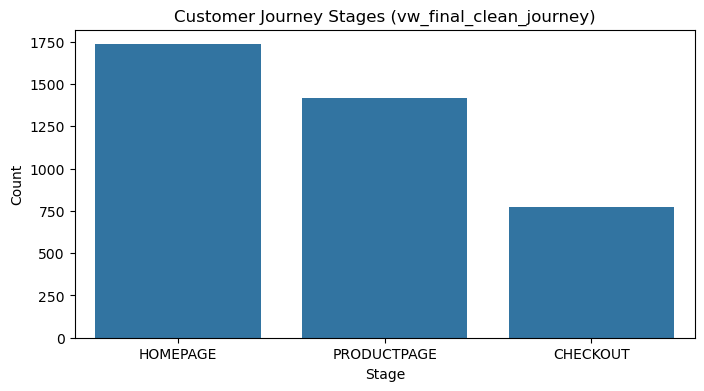

In [81]:
journey_stage = journey.dropna(subset=['CleanStage'])

plt.figure(figsize=(8,4))
sns.countplot(data=journey_stage, x='CleanStage')
plt.title('Customer Journey Stages (vw_final_clean_journey)')
plt.xlabel('Stage')
plt.ylabel('Count')
plt.show()

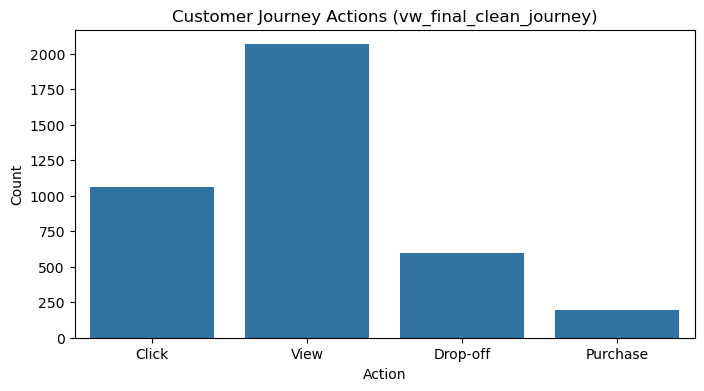

In [82]:
journey_action = journey.dropna(subset=['Action'])

plt.figure(figsize=(8,4))
sns.countplot(data=journey_action, x='Action')
plt.title('Customer Journey Actions (vw_final_clean_journey)')
plt.xlabel('Action')
plt.ylabel('Count')
plt.show()


## Analytics

## Monthly Customer Journey Insight

The monthly customer journey trend helps determine whether performance decline is caused by reduced customer traffic or low engagement levels.

If journeys are decreasing, it indicates a drop in customer visits.  
If journeys remain stable while engagement declines, it suggests that customers are present but not interacting effectively.

**Problem Solved**  
This analysis identifies whether the issue is:
- Low customer traffic, or  
- Low customer engagement.

This insight supports better decisions to either increase acquisition efforts or improve content and campaign performance.


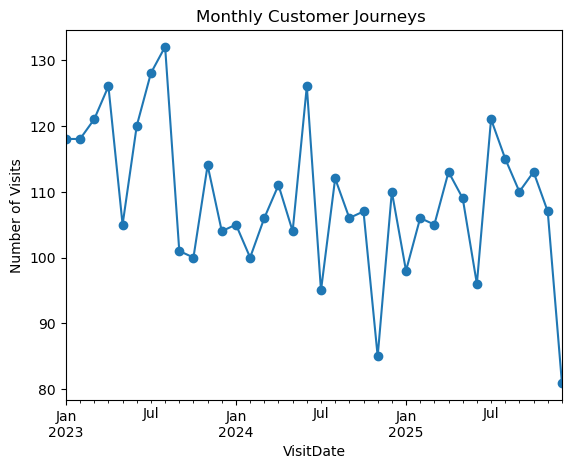

In [86]:

journey['VisitDate'] = pd.to_datetime(journey['VisitDate'])
visits_by_month = journey.groupby(
    journey['VisitDate'].dt.to_period('M')
).size()
visits_by_month.plot(
    kind='line',
    marker='o',
    title='Monthly Customer Journeys '
)
plt.ylabel('Number of Visits')
plt.show()


## Daily Engagement Insight

Daily engagement shows a declining pattern over time, indicating reduced user interaction.

Problem solved: Detects decrease in user interest early.
 

<Axes: title={'center': 'Daily Engagement Trend'}, xlabel='EngagementDate'>

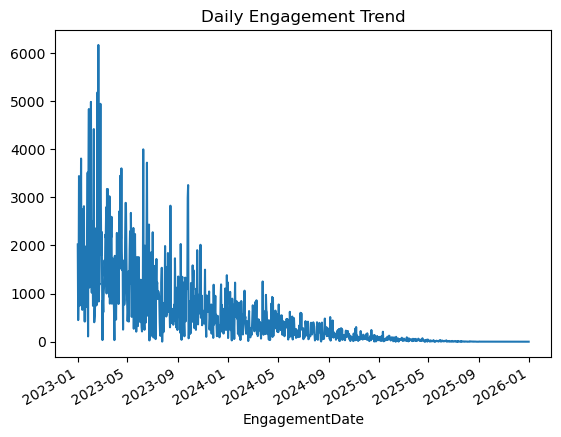

In [71]:
daily_engagement = engagement.groupby('EngagementDate')['Likes'].sum()

daily_engagement.plot(title="Daily Engagement Trend")


## Content Performance Insight 




  
Engagement analysis by content type identifies the most effective content formats.
Problem solved: Helps optimize content strategy 

<Axes: title={'center': 'Engagement by Content Type'}, xlabel='CleanContentType'>

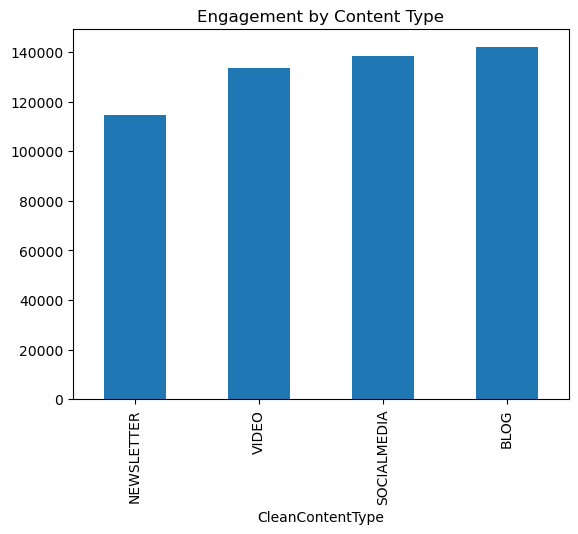

In [72]:
content_perf = engagement.groupby('CleanContentType')['Likes'].sum()

content_perf.sort_values().plot(kind='bar', title="Engagement by Content Type")


## Calendar Analysis
Analysis identifies the days with the highest user engagement.

Problem solved: Optimizes posting schedule



<Axes: title={'center': 'Engagement by Day'}, xlabel='DayOfWeek'>

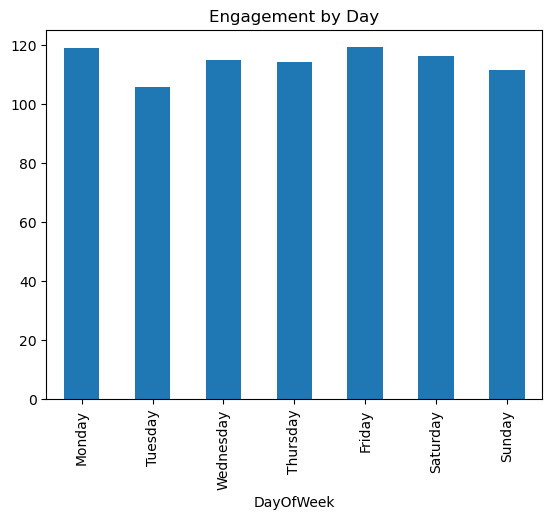

In [73]:
engagement['DayOfWeek'] = engagement['EngagementDate'].dt.day_name()

day_perf = engagement.groupby('DayOfWeek')['Likes'].mean()

day_perf = day_perf.reindex([
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
])

day_perf.plot(kind='bar', title="Engagement by Day")


## Funnel Analysis
Funnel Analysis
The funnel identifies the stage with the highest customer drop-off.

Problem solved: Detects conversion bottlenecks


<Axes: title={'center': 'Customer Journey Funnel'}, xlabel='CleanStage'>

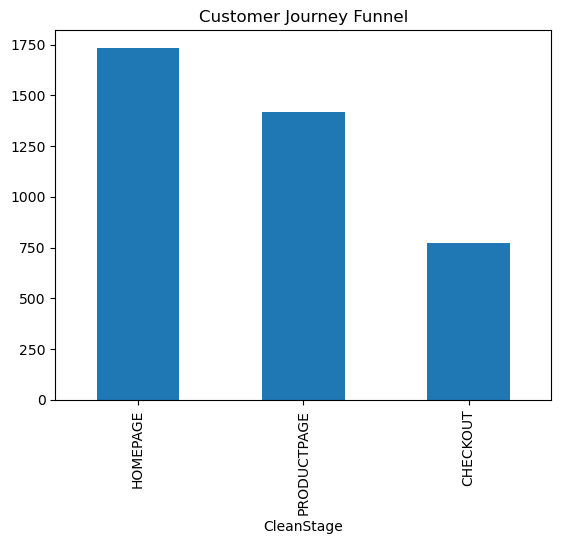

In [74]:
funnel = journey['CleanStage'].value_counts()

funnel.plot(kind='bar', title="Customer Journey Funnel")


## Rating Distribution
Customer ratings analysis helps measure overall satisfaction levels.

Problem solved: Identifies service or product quality issues

<Axes: title={'center': 'Rating Distribution'}, xlabel='Rating'>

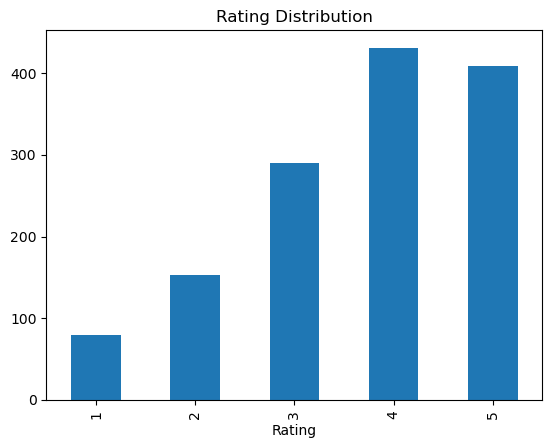

In [75]:
rating_dist = reviews['Rating'].value_counts().sort_index()
rating_dist.plot(kind='bar', title="Rating Distribution")


## Sentiment Analysis
Text sentiment analysis reveals customer emotions and hidden satisfaction trends.

Problem solved: Detects customer dissatisfaction from text feedback

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already u

Finished.


<Axes: >

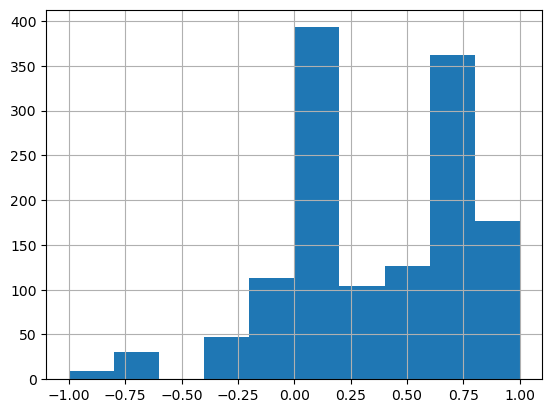

In [76]:
!pip install textblob
!python -m textblob.download_corpora
from textblob import TextBlob

reviews['Sentiment'] = reviews['ReviewText'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

reviews['Sentiment'].hist()


## Forecast Insight
The engagement forecast shows a continued decline in future periods, indicating that current marketing strategies may not be effective. Immediate optimization of content and campaign performance is required to prevent further engagement loss.

Problem solved:
Helps identify future performance risks and supports proactive marketing decisions.

C:\Users\user\AppData\Local\Temp\ipykernel_10924\4278290785.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='EngagementDate', freq='M')
C:\Users\user\AppData\Local\Temp\ipykernel_10924\4278290785.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


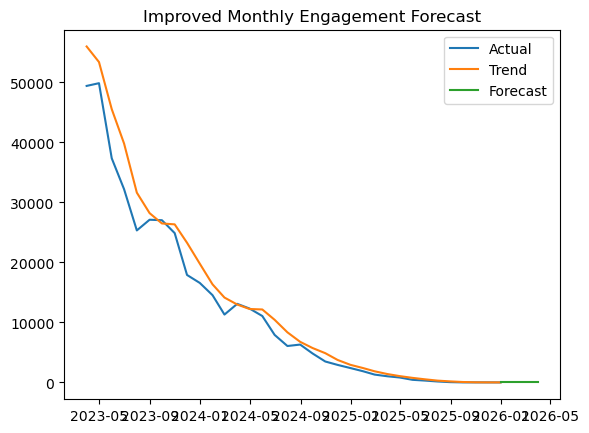

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

engagement['EngagementDate'] = pd.to_datetime(engagement['EngagementDate'])

monthly_engagement = engagement.groupby(
    pd.Grouper(key='EngagementDate', freq='M')
)['Likes'].sum().reset_index()

monthly_engagement = monthly_engagement.dropna()

monthly_engagement['MA_3'] = monthly_engagement['Likes'].rolling(3).mean()
monthly_engagement = monthly_engagement.dropna()

monthly_engagement['DateOrdinal'] = monthly_engagement['EngagementDate'].map(pd.Timestamp.toordinal)

model = LinearRegression()
model.fit(monthly_engagement[['DateOrdinal']], monthly_engagement['MA_3'])

future_dates = pd.date_range(
    monthly_engagement['EngagementDate'].max(),
    periods=4,
    freq='M'
)

future_df = pd.DataFrame({
    'EngagementDate': future_dates
})

future_df['DateOrdinal'] = future_df['EngagementDate'].map(pd.Timestamp.toordinal)
future_df['PredictedLikes'] = model.predict(future_df[['DateOrdinal']])
future_df['PredictedLikes'] = future_df['PredictedLikes'].clip(lower=0)

plt.figure()
plt.plot(monthly_engagement['EngagementDate'], monthly_engagement['Likes'], label='Actual')
plt.plot(monthly_engagement['EngagementDate'], monthly_engagement['MA_3'], label='Trend')
plt.plot(future_df['EngagementDate'], future_df['PredictedLikes'], label='Forecast')
plt.legend()
plt.title("Improved Monthly Engagement Forecast")
plt.show()
